# Colebrook White Equation with MIDL
 Run `MIDL` to discover dominant dimensionless groups.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current_notebook_dir = os.getcwd()
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '..', '..'))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)

import midl
MIDL = midl.MIDL
calc_basis = midl.calc_basis


In [2]:
# Colebrook-White equation function to solve for friction factor f
def colebrook(Re, ks_D):
    # Initial guess for friction factor (Blasius correlation for smooth pipe)
    f = 0.079 / Re**0.25
    # Iterative solution for Colebrook-White equation
    for i in range(100):
        f_new = 1 / (-1 * np.log10((ks_D / 3.7) + (5.02 / (Re * np.sqrt(f)))))
        if abs(f_new - f) < 1e-6:  # Convergence criterion
            f = f_new
            break
        f = f_new
    Cf = f 
    return Cf

# Define the sample size
n_samples = 100000  # or any desired number
mu        = 0.001  # Example constant value in Pa.s
## IF REYNOLDS NUMBER AND RELATIVE ROUGHNESS ARE LOG UNIFORM DISTRIBUTED
log_Re                 = np.random.uniform(3, 5, n_samples)  
log_relative_roughness = np.random.uniform(-8, -0.7, n_samples)  
Re                     = 10**log_Re
relative_roughness     = 10**log_relative_roughness
rho = 200  # Example constant density (kg/m^3)
D   = np.random.uniform(1, 10, n_samples)
k   = relative_roughness * D  # Roughness height (m)
U   = (Re * mu) / (rho * D)  # Velocity (m/s)
Cf  = np.zeros(n_samples)
for i in range(n_samples):
    Cf[i] = colebrook(Re[i], relative_roughness[i])
print(f'Relative roughness range: {relative_roughness.min()} - {relative_roughness.max()}')
print(f'Reynolds number range: {Re.min()} - {Re.max()}')    


Relative roughness range: 1.0001014815369025e-08 - 0.19949972885041478
Reynolds number range: 1000.0559940416998 - 99995.69509008496


In [3]:
X_raw              = np.column_stack((U, rho * np.ones(n_samples), D, k, mu * np.ones(n_samples)))
# Output matrix Y (Skin Friction Coefficient Cf)
Y              = Cf.reshape(-1, 1)
D_in           = np.matrix('1 -3 1 1 -1; -1 0 0 0 -1; 0 1 0 0 1')

# Compute basis and construct independent dimensionless groups Pi
basis, r = calc_basis(D_in)
print('Null space dimension:', D_in.shape[1] - r)
print('basis:\n', basis)

Pi = np.exp(np.log(X_raw) @ basis)


Null space dimension: 2
basis:
 [[ 0.07839067 -0.52874303]
 [ 0.07839067 -0.52874303]
 [-0.66026594 -0.36807262]
 [ 0.73865661 -0.16067041]
 [-0.07839067  0.52874303]]


/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_67375/2867351792.py:11: RuntimeWarning: divide by zero encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)
/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_67375/2867351792.py:11: RuntimeWarning: overflow encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)
/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_67375/2867351792.py:11: RuntimeWarning: invalid value encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)


In [4]:
# Run MIDL
model = MIDL(
    k_neighbors=6,
    de_maxiter=200,
    de_popsize=15,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=Y, threshold=10)
pi_hat = MIDL.compose_new_pi(Pi, result['W'])

print('\n=== MIDL Results ===')
print('MI scores:', result['mi_scores'])
print('dominant_q:', result['dominant_q'])
print('drop ratios I_i / I_(i+1):', result['drop_ratios'])

# Exponents in original variable space
alpha = basis @ result['W']
print('\n=== Recovered exponents in original variables ===')
print(alpha)


[Step 1] MI = 3.456249
[Step 2] MI = 0.588845
   ratio = 5.870

=== MIDL Results ===
MI scores: [3.45624884 0.58884543]
dominant_q: 2
drop ratios I_i / I_(i+1): None

=== Recovered exponents in original variables ===
[[ 4.99984183e-01 -1.89024079e-01]
 [ 4.99984183e-01 -1.89024079e-01]
 [ 5.00047444e-01  5.66904864e-01]
 [-6.32612391e-05 -7.55928943e-01]
 [-4.99984183e-01  1.89024079e-01]]


/Users/baoyuan/Documents/MI_DL/midl.py:180: RuntimeWarning: divide by zero encountered in matmul
  xhat = X @ W
/Users/baoyuan/Documents/MI_DL/midl.py:180: RuntimeWarning: overflow encountered in matmul
  xhat = X @ W
/Users/baoyuan/Documents/MI_DL/midl.py:180: RuntimeWarning: invalid value encountered in matmul
  xhat = X @ W
/Users/baoyuan/Documents/MI_DL/midl.py:195: RuntimeWarning: divide by zero encountered in matmul
  xhat = X @ W
/Users/baoyuan/Documents/MI_DL/midl.py:195: RuntimeWarning: overflow encountered in matmul
  xhat = X @ W
/Users/baoyuan/Documents/MI_DL/midl.py:195: RuntimeWarning: invalid value encountered in matmul
  xhat = X @ W


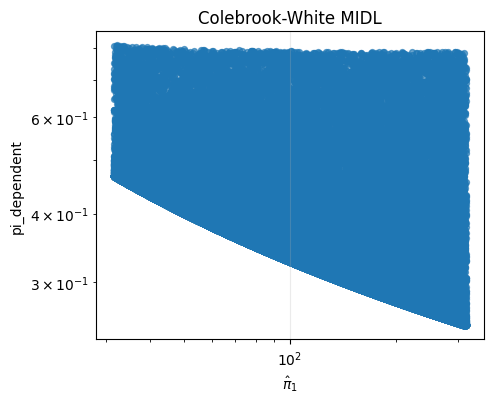

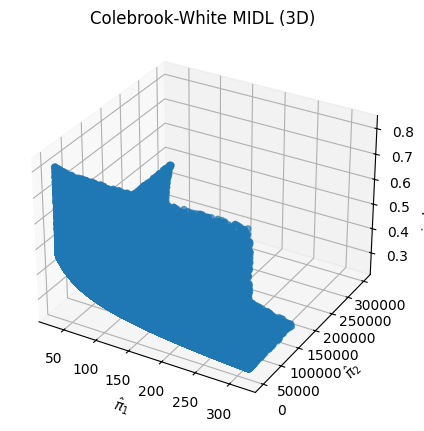

In [5]:
# Plot: 2D always, and extra 3D when dominant_q >= 2
if result['dominant_q'] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Colebrook-White MIDL',
        log_scale=True,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Colebrook-White MIDL',
        log_scale=True,
    )
plt.show()
